# Applied Machine Learning: Model Design, Training, and Performance Evaluation

Author: Sukh Sandhu

This notebook trains and evaluates a reproducible supervised classifier on the Breast Cancer Wisconsin Diagnostic dataset.

In [1]:

        from pathlib import Path
        import json
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
        from sklearn.model_selection import train_test_split
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler

        DATA_PATH = Path('data/breast_cancer_wisconsin.csv')
        FIG_DIR = Path('figures')
        OUT_DIR = Path('outputs')
        FIG_DIR.mkdir(exist_ok=True)
        OUT_DIR.mkdir(exist_ok=True)
        

## Data Preparation

In [2]:

        df = pd.read_csv(DATA_PATH)
        display(df.head())
        X = df.drop(columns=['target', 'diagnosis'])
        y = df['target']
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=y
        )
        print(X_train.shape, X_test.shape)
        display(y.value_counts().rename(index={0: 'malignant', 1: 'benign'}).to_frame('count'))
        

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


(426, 30) (143, 30)


,count
target,
benign,357
malignant,212


## Model Definition and Training

In [3]:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=5000, random_state=42))
        ])
        model.fit(X_train, y_train)
        

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143

ROC AUC: 0.9977


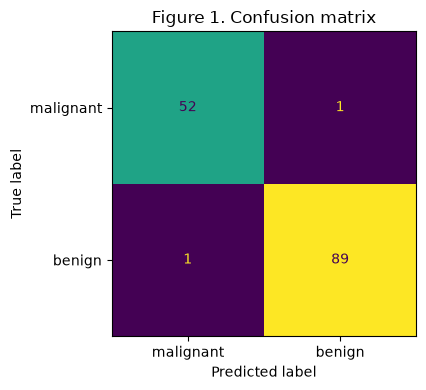

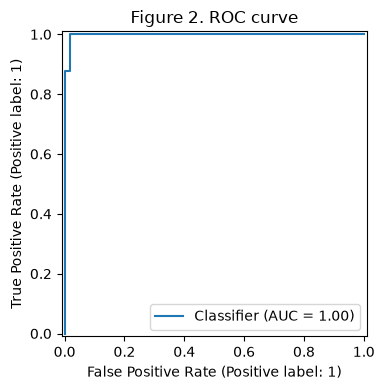

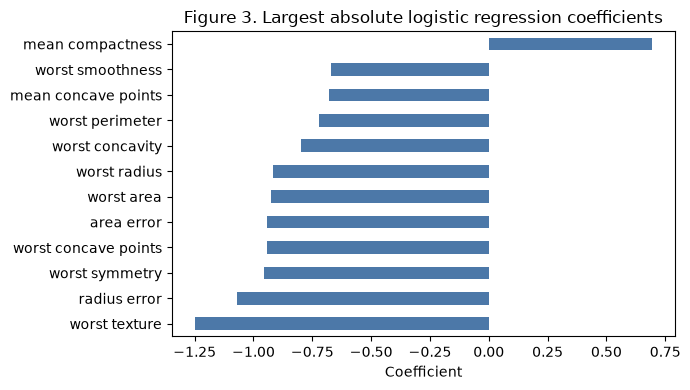

In [4]:

        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        report = classification_report(y_test, preds, target_names=['malignant', 'benign'], output_dict=True)
        print(classification_report(y_test, preds, target_names=['malignant', 'benign']))
        auc = roc_auc_score(y_test, probs)
        print(f'ROC AUC: {auc:.4f}')

        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=['malignant', 'benign'], ax=ax, colorbar=False)
        ax.set_title('Figure 1. Confusion matrix')
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'figure_1_confusion_matrix.png', dpi=160)
        plt.show()

        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_predictions(y_test, probs, ax=ax)
        ax.set_title('Figure 2. ROC curve')
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'figure_2_roc_curve.png', dpi=160)
        plt.show()

        coefficients = pd.Series(model.named_steps['classifier'].coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False).head(12)
        fig, ax = plt.subplots(figsize=(7, 4))
        coefficients.sort_values().plot(kind='barh', ax=ax, color='#4C78A8')
        ax.set_title('Figure 3. Largest absolute logistic regression coefficients')
        ax.set_xlabel('Coefficient')
        fig.tight_layout()
        fig.savefig(FIG_DIR / 'figure_3_coefficients.png', dpi=160)
        plt.show()
        

## Notebook Summary

The logistic-regression pipeline uses standard scaling and a stratified train-test split to keep preprocessing reproducible. The model produced high test-set performance on this benchmark dataset, but the confusion matrix remains important because false benign predictions would be high risk in a real screening context. The ROC curve shows strong separation, and the coefficient plot helps identify influential measurements. The workflow should be validated on external data before any real clinical use.

In [5]:

        cm = confusion_matrix(y_test, preds)
        metrics = {
            'rows': int(df.shape[0]),
            'columns': int(df.shape[1]),
            'accuracy': float(report['accuracy']),
            'malignant_precision': float(report['malignant']['precision']),
            'malignant_recall': float(report['malignant']['recall']),
            'benign_precision': float(report['benign']['precision']),
            'benign_recall': float(report['benign']['recall']),
            'roc_auc': float(auc),
            'confusion_matrix': cm.tolist(),
            'top_features': coefficients.index.tolist()
        }
        with open(OUT_DIR / 'metrics.json', 'w', encoding='utf-8') as f:
            json.dump(metrics, f, indent=2)
        metrics
        

{'rows': 569,
 'columns': 32,
 'accuracy': 0.986013986013986,
 'malignant_precision': 0.9811320754716981,
 'malignant_recall': 0.9811320754716981,
 'benign_precision': 0.9888888888888889,
 'benign_recall': 0.9888888888888889,
 'roc_auc': 0.9976939203354298,
 'confusion_matrix': [[52, 1], [1, 89]],
 'top_features': ['worst texture',
  'radius error',
  'worst symmetry',
  'worst concave points',
  'area error',
  'worst area',
  'worst radius',
  'worst concavity',
  'worst perimeter',
  'mean compactness',
  'mean concave points',
  'worst smoothness']}